In [26]:
# =============================================================================
# PARAMETERS — imports, constants, paths
# =============================================================================
import os
import glob
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="pyresample")

import numpy as np
import h5py
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from rasterio.merge import merge
from rasterio.windows import from_bounds as window_from_bounds
from pyproj import CRS, Transformer

try:
    from pyresample import geometry, image
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyresample"])
    from pyresample import geometry, image

# -----------------------------------------------------------------------------
# Matplotlib backend — try widget for interactivity, fallback to inline
# -----------------------------------------------------------------------------
try:
    import ipympl
    get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    try:
        get_ipython().run_line_magic("matplotlib", "inline")
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Project root — cwd if run from project root, else parent of notebooks/
# -----------------------------------------------------------------------------
_cwd = os.getcwd()
PROJECT_ROOT = os.path.normpath(os.path.join(_cwd, "..")) if os.path.basename(_cwd) == "notebooks" else _cwd

# -----------------------------------------------------------------------------
# Paths (relative to project root)
# -----------------------------------------------------------------------------
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

VIIRS_DIR = os.path.join(PROJECT_ROOT, "data", "viirs")
_h5_files = glob.glob(os.path.join(VIIRS_DIR, "*.h5"))

if _h5_files:
    HDF5_PATH = _h5_files[0]
    if len(_h5_files) > 1:
        print(f"Multiple HDF5 files found; using: {HDF5_PATH}")
else:
    HDF5_PATH = os.path.join(VIIRS_DIR, "GITCO-SVI01-SVI02-SVI03-SVI04-SVI05_npp_d20260125_t2315015_e2320401_b73826_c20260127210812288114_oeac_ops.h5")
    print(f"No HDF5 in data/viirs/; will use path: {HDF5_PATH}")

OCC_GLOB = os.path.join(PROJECT_ROOT, "data", "gsw", "occurrence_alaska_tiles", "occurrence_*_*.tif")
SEA_GLOB = os.path.join(PROJECT_ROOT, "data", "gsw", "seasonality_alaska_tiles", "seasonality_*_*.tif")

# -----------------------------------------------------------------------------
# AOI and resolution
# -----------------------------------------------------------------------------
AOI_BBOX = (54,72,-171,-129)  # lat_min, lat_max, lon_min, lon_max
RESOLUTION_M = 375.0
RESOLUTION_30M = 30.0
PAD_30M = 30.0  # pad extent by one 30m pixel on all sides
N_PIXELS_LAND = 1
N_PIXELS_MIXED = 5
N_PIXELS_WATER = 3



In [27]:
# =============================================================================
# PREFLIGHT — AOI memory check (sandbox test before full pipeline)
# =============================================================================
# Estimates 30m crop size and memory. No heavy data loaded. Run this cell first
# to verify your AOI is within limits before running DATA LOADING.

import math
MAX_PIXELS = 80_000_000  # same as load_jrc_crop_safe

lat_min, lat_max, lon_min, lon_max = AOI_BBOX
lat_span = lat_max - lat_min
lon_span = lon_max - lon_min
lat_center = 0.5 * (lat_min + lat_max)

# Approximate meters: 1 deg lat ~ 111 km; 1 deg lon ~ 111 * cos(lat) km
m_per_deg_lat = 111_000
m_per_deg_lon = 111_000 * math.cos(math.radians(lat_center))
lat_m = lat_span * m_per_deg_lat
lon_m = lon_span * m_per_deg_lon

# 30m pixels
n_cols_30m = int(math.ceil(lon_m / RESOLUTION_30M))
n_rows_30m = int(math.ceil(lat_m / RESOLUTION_30M))
n_pix_30m = n_rows_30m * n_cols_30m

# 375m pixels (for reference)
n_cols_375m = int(math.ceil(lon_m / RESOLUTION_M))
n_rows_375m = int(math.ceil(lat_m / RESOLUTION_M))
n_pix_375m = n_rows_375m * n_cols_375m

# Rough memory: occurrence/seasonality uint8 = 1 B/px; float32 = 4 B/px
# Per product: 1 + 4 bytes (uint8 crop + float32) ~ 5 B/px. Two products = 10 B/px.
mem_mb_30m = n_pix_30m * 10 / (1024 * 1024)

print("PREFLIGHT — AOI memory check")
print("-" * 50)
print(f"AOI: lat [{lat_min}, {lat_max}], lon [{lon_min}, {lon_max}]")
print(f"Span: {lat_span:.2f}° lat x {lon_span:.2f}° lon")
print(f"30m crop: ~{n_rows_30m} x {n_cols_30m} = {n_pix_30m:,} pixels")
print(f"375m grid: ~{n_rows_375m} x {n_cols_375m} = {n_pix_375m:,} pixels")
print(f"Est. memory (30m products): ~{mem_mb_30m:.0f} MB")
if n_pix_30m > MAX_PIXELS:
    print(f"WARNING: {n_pix_30m:,} > {MAX_PIXELS:,} max. Reduce AOI.")
else:
    print(f"OK: under {MAX_PIXELS:,} pixel limit.")
print("-" * 50)



PREFLIGHT — AOI memory check
--------------------------------------------------
AOI: lat [54, 72], lon [-171, -129]
Span: 18.00° lat x 42.00° lon
30m crop: ~66600 x 70551 = 4,698,696,600 pixels
375m grid: ~5328 x 5645 = 30,076,560 pixels
Est. memory (30m products): ~44810 MB
--------------------------------------------------


In [58]:
# =============================================================================
# HELPERS — all functions, no execution
# =============================================================================

def discover_viirs_paths(h5):
    """Find Latitude, Longitude, and I1–I5 band paths in VIIRS GITCO/SVI HDF5."""
    def list_datasets(obj, prefix=""):
        paths = []
        for key in obj.keys():
            p = f"{prefix}/{key}" if prefix else key
            if isinstance(obj[key], h5py.Dataset):
                paths.append(p)
            else:
                paths.extend(list_datasets(obj[key], p))
        return paths
    datasets = list_datasets(h5)
    paths = {}
    for kind in ["Latitude", "Longitude"]:
        cand = [p for p in datasets if "GEO" in p and kind in p]
        if not cand:
            cand = [p for p in datasets if "GITCO" in p and kind in p]
        if cand:
            paths[kind.lower()] = cand[0]
    if "latitude" not in paths or "longitude" not in paths:
        raise KeyError("Could not find Latitude/Longitude in HDF5")
    for band in range(1, 6):
        token = f"VIIRS-I{band}-SDR_All"
        names = ["Reflectance", "Radiance"] if band <= 3 else ["BrightnessTemperature", "Radiance"]
        for name in names:
            cand = [p for p in datasets if token in p and p.endswith(name)]
            if cand:
                paths[f"I{band}"] = cand[0]
                break
        if f"I{band}" not in paths:
            raise KeyError(f"Could not find I{band} dataset")
    return paths


def discover_band_scaling(h5, band_path):
    """Get scale/offset from band attrs or companion *Factors dataset."""
    result = {"scale": None, "offset": None, "fill_value": None, "valid_range": None}
    attrs = h5[band_path].attrs
    for k, v in attrs.items():
        kk = k.lower()
        if "scale" in kk or kk == "scalefactor":
            result["scale"] = float(np.asarray(v).ravel()[0])
        elif "offset" in kk or kk == "addoffset":
            result["offset"] = float(np.asarray(v).ravel()[0])
        elif "fill" in kk:
            result["fill_value"] = float(np.asarray(v).ravel()[0])
        elif "valid" in kk and "range" in kk:
            arr = np.asarray(v).ravel()
            if arr.size >= 2:
                result["valid_range"] = (float(arr[0]), float(arr[1]))
    parts = band_path.split("/")
    factors_path = "/".join(parts[:-1]) + "/" + parts[-1] + "Factors"
    if factors_path in h5 and isinstance(h5[factors_path], h5py.Dataset):
        fac = np.asarray(h5[factors_path][...]).ravel()
        if result["scale"] is None and len(fac) >= 1:
            result["scale"] = float(fac[0])
        if result["offset"] is None and len(fac) >= 2:
            result["offset"] = float(fac[1])
    return result


def apply_band_scaling(raw, scaling):
    """Apply scale/offset, mask fill and invalid. Returns float32."""
    out = raw.astype(np.float32, copy=True)
    mask_invalid = (out == 63999) | (out == 65533) | (out > 65529)
    out[mask_invalid] = np.nan
    if scaling.get("fill_value") is not None:
        out[out == scaling["fill_value"]] = np.nan
    if scaling.get("valid_range") is not None:
        vmin, vmax = scaling["valid_range"]
        out[(out < vmin) | (out > vmax)] = np.nan
    s, o = scaling.get("scale"), scaling.get("offset")
    if s is not None and o is not None:
        out = out * s + o
    elif s is not None:
        out = out * s
    elif o is not None:
        out = out + o
    return out


def load_viirs_swath(hdf5_path):
    """Load lat, lon, and scaled I1–I5 from VIIRS HDF5."""
    hdf5_path = os.path.expanduser(hdf5_path)
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"HDF5 not found: {hdf5_path}")
    with h5py.File(hdf5_path, "r") as h5:
        paths = discover_viirs_paths(h5)
        lat = h5[paths["latitude"]][...].astype(np.float32)
        lon = h5[paths["longitude"]][...].astype(np.float32)
        lat[(lat < -90) | (lat > 90)] = np.nan
        lon[(lon < -180) | (lon > 180)] = np.nan
        bands = {}
        for i in range(1, 6):
            bp = paths[f"I{i}"]
            raw = h5[bp][...]
            scaling = discover_band_scaling(h5, bp)
            bands[f"I{i}"] = apply_band_scaling(raw, scaling)
    return lat, lon, bands


def bbox_intersects(bounds, aoi_bbox):
    """bounds: (left, bottom, right, top) in EPSG:4326."""
    left, bottom, right, top = bounds
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    aoi_left, aoi_bottom, aoi_right, aoi_top = lon_min, lat_min, lon_max, lat_max
    return not (right < aoi_left or left > aoi_right or top < aoi_bottom or bottom > aoi_top)


def find_jrc_tiles_for_aoi(aoi_bbox, tile_glob):
    paths = sorted(glob.glob(tile_glob))
    if not paths:
        raise FileNotFoundError(f"No JRC tiles found at: {tile_glob}")
    hit = []
    for p in paths:
        with rasterio.open(p) as src:
            if src.crs is not None and bbox_intersects(src.bounds, aoi_bbox):
                hit.append(p)
    if not hit:
        raise FileNotFoundError(f"No JRC tiles intersect AOI_BBOX. Tiles: {len(paths)}")
    return hit


def load_jrc_crop_safe(aoi_bbox, tile_glob, max_pixels=80_000_000):
    """RAM-safe: merge with bounds= to crop during merge."""
    lat_min, lat_max, lon_min, lon_max = aoi_bbox
    west, south, east, north = lon_min, lat_min, lon_max, lat_max
    lat_span = lat_max - lat_min
    lon_span = lon_max - lon_min
    if lat_span > 10 or lon_span > 25:
        raise ValueError(
            f"AOI too large ({lat_span:.1f}° lat x {lon_span:.1f}° lon). "
            "Use smaller AOI (few degrees)."
        )
    tile_paths = find_jrc_tiles_for_aoi(aoi_bbox, tile_glob)
    srcs = [rasterio.open(p) for p in tile_paths]
    try:
        crs = srcs[0].crs
        if crs is None:
            raise ValueError("JRC tiles have no CRS. Re-export with EPSG:4326.")
        mosaic, mosaic_transform = merge(srcs, bounds=(west, south, east, north))
        arr = mosaic[0].astype(np.uint8)
        n_pix = int(arr.shape[0]) * int(arr.shape[1])
        if n_pix > max_pixels:
            raise MemoryError(f"Crop too large: {n_pix:,} pixels. Reduce AOI.")
        return arr, (west, south, east, north), crs
    finally:
        for s in srcs:
            s.close()


def choose_utm_crs(lon0, lat0):
    zone = int((lon0 + 180) / 6) + 1
    epsg = 32600 + zone if lat0 >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def swath_to_grid(lat, lon, values, dst_crs, dst_res_m, bbox_latlon):
    if geometry is None or image is None:
        raise ImportError("pyresample required")
    lat_min, lat_max, lon_min, lon_max = bbox_latlon
    trans_to_utm = Transformer.from_crs("EPSG:4326", dst_crs, always_xy=True)
    buf = 0.5
    in_aoi = (lat >= lat_min - buf) & (lat <= lat_max + buf) & (lon >= lon_min - buf) & (lon <= lon_max + buf)
    valid = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(values) & in_aoi
    lats_m = np.ma.masked_array(lat, mask=~valid)
    lons_m = np.ma.masked_array(lon, mask=~valid)
    data_m = np.ma.masked_array(values.astype(np.float32), mask=~valid)
    corners_ll = [(lon_min, lat_min), (lon_max, lat_min), (lon_max, lat_max), (lon_min, lat_max)]
    corners_utm = [trans_to_utm.transform(x, y) for x, y in corners_ll]
    x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
    y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / dst_res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / dst_res_m)))
    area_extent = (x_min, y_min, x_max, y_max)
    lon0, lat0 = 0.5 * (lon_min + lon_max), 0.5 * (lat_min + lat_max)
    zone = int((lon0 + 180) / 6) + 1
    proj_dict = {"proj": "utm", "zone": zone, "ellps": "WGS84", "units": "m"}
    area_def = geometry.AreaDefinition("viirs_utm", "VIIRS UTM", "viirs_utm", proj_dict, width, height, area_extent)
    swath_def = geometry.SwathDefinition(lons=lons_m, lats=lats_m)
    swath_con = image.ImageContainerNearest(data_m, swath_def, radius_of_influence=7000, epsilon=0.375, nprocs=1)
    area_con = swath_con.resample(area_def)
    arr = area_con.image_data
    result = np.ma.filled(arr, fill_value=np.nan).astype(np.float32) if np.ma.is_masked(arr) else np.asarray(arr, dtype=np.float32)
    transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    return result, transform


def reproject_to_utm_30m(src_data, src_bounds, src_crs, dst_crs, res_m=30, resampling=Resampling.bilinear, target_extent=None, pad_m=0):
    """Reproject to UTM 30m. If target_extent given, pad by pad_m on all sides."""
    west, south, east, north = src_bounds
    if target_extent is not None:
        x_min, y_min, x_max, y_max = target_extent
        if pad_m > 0:
            x_min -= pad_m
            y_min -= pad_m
            x_max += pad_m
            y_max += pad_m
    else:
        trans = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        corners_ll = [(west, south), (east, south), (east, north), (west, north)]
        corners_utm = [trans.transform(x, y) for x, y in corners_ll]
        x_min, x_max = min(c[0] for c in corners_utm), max(c[0] for c in corners_utm)
        y_min, y_max = min(c[1] for c in corners_utm), max(c[1] for c in corners_utm)
    width = max(1, int(np.ceil((x_max - x_min) / res_m)))
    height = max(1, int(np.ceil((y_max - y_min) / res_m)))
    dst_transform = from_bounds(x_min, y_min, x_max, y_max, width, height)
    src_transform = from_bounds(west, south, east, north, src_data.shape[1], src_data.shape[0])
    src_nan = np.where(np.isfinite(src_data), src_data, np.nan)
    dst_data = np.full((height, width), np.nan, dtype=np.float32)
    reproject(source=src_nan, destination=dst_data, src_transform=src_transform, src_crs=src_crs,
             src_nodata=np.nan, dst_transform=dst_transform, dst_crs=dst_crs, dst_nodata=np.nan, resampling=resampling)
    return dst_data, dst_transform


def _assert_north_up(transform, name="transform"):
    """Assert transform has no rotation (north-up raster)."""
    b, d = transform.b, transform.d
    if abs(b) >= 1e-9 or abs(d) >= 1e-9:
        raise ValueError(
            f"{name} has rotation (b={b}, d={d}). "
            "Area-weighted rectangle overlap requires north-up rasters. Use shapely for rotated rasters."
        )


def aggregate_area_weighted_rectangles(data_30m, tf_30m, tf_375m, shape_375m):
    """
    Area-weighted aggregation of 30m water fraction to 375m grid using exact rectangle overlap.
    Numerator: sum(value_i * overlap_frac_i) for finite 30m pixels only.
    Denominator: sum(overlap_frac_i) over ALL intersecting 30m pixels (including nodata).
    wf_375 = weighted_water / total_overlap. North-up rasters only.
    """
    _assert_north_up(tf_30m, "tf_30m")
    _assert_north_up(tf_375m, "tf_375m")

    area_30m_px = abs(tf_30m.a) * abs(tf_30m.e)
    out = np.full(shape_375m, np.nan, dtype=np.float32)
    nrows, ncols = shape_375m

    for r in range(nrows):
        for c in range(ncols):
            # 375m pixel bounds (left, bottom, right, top) in UTM
            x_ul = tf_375m.c + c * tf_375m.a
            y_ul = tf_375m.f + r * tf_375m.e
            x_lr = tf_375m.c + (c + 1) * tf_375m.a
            y_lr = tf_375m.f + (r + 1) * tf_375m.e
            l_375 = min(x_ul, x_lr)
            r_375 = max(x_ul, x_lr)
            b_375 = min(y_ul, y_lr)
            t_375 = max(y_ul, y_lr)

            win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30m)
            col_off = int(max(0, win.col_off))
            row_off = int(max(0, win.row_off))
            w = int(win.width)
            h = int(win.height)
            col_end = min(col_off + w, data_30m.shape[1])
            row_end = min(row_off + h, data_30m.shape[0])

            weighted_water = 0.0
            total_overlap = 0.0

            for j in range(col_off, col_end):
                for i in range(row_off, row_end):
                    # 30m pixel bounds
                    x_ul_30 = tf_30m.c + j * tf_30m.a
                    y_ul_30 = tf_30m.f + i * tf_30m.e
                    x_lr_30 = tf_30m.c + (j + 1) * tf_30m.a
                    y_lr_30 = tf_30m.f + (i + 1) * tf_30m.e
                    l_30 = min(x_ul_30, x_lr_30)
                    r_30 = max(x_ul_30, x_lr_30)
                    b_30 = min(y_ul_30, y_lr_30)
                    t_30 = max(y_ul_30, y_lr_30)

                    overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
                    overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
                    overlap_area = overlap_w * overlap_h
                    overlap_fraction = overlap_area / area_30m_px

                    total_overlap += overlap_fraction
                    val = data_30m[i, j]
                    if np.isfinite(val):
                        weighted_water += val * overlap_fraction

            if total_overlap > 0:
                out[r, c] = weighted_water / total_overlap

    return out


def inspect_375m_pixel_area_weighted(r, c, data_30m, data_375m, tf_30m, tf_375m):
    """Verify single 375m pixel using same rectangle overlap logic."""
    _assert_north_up(tf_30m, "tf_30m")
    _assert_north_up(tf_375m, "tf_375m")

    area_30m_px = abs(tf_30m.a) * abs(tf_30m.e)
    x_ul = tf_375m.c + c * tf_375m.a
    y_ul = tf_375m.f + r * tf_375m.e
    x_lr = tf_375m.c + (c + 1) * tf_375m.a
    y_lr = tf_375m.f + (r + 1) * tf_375m.e
    l_375 = min(x_ul, x_lr)
    r_375 = max(x_ul, x_lr)
    b_375 = min(y_ul, y_lr)
    t_375 = max(y_ul, y_lr)

    win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30m)
    col_off = int(max(0, win.col_off))
    row_off = int(max(0, win.row_off))
    w = int(win.width)
    h = int(win.height)
    col_end = min(col_off + w, data_30m.shape[1])
    row_end = min(row_off + h, data_30m.shape[0])

    weighted_water = 0.0
    total_overlap = 0.0

    for j in range(col_off, col_end):
        for i in range(row_off, row_end):
            x_ul_30 = tf_30m.c + j * tf_30m.a
            y_ul_30 = tf_30m.f + i * tf_30m.e
            x_lr_30 = tf_30m.c + (j + 1) * tf_30m.a
            y_lr_30 = tf_30m.f + (i + 1) * tf_30m.e
            l_30 = min(x_ul_30, x_lr_30)
            r_30 = max(x_ul_30, x_lr_30)
            b_30 = min(y_ul_30, y_lr_30)
            t_30 = max(y_ul_30, y_lr_30)

            overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
            overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
            overlap_area = overlap_w * overlap_h
            overlap_fraction = overlap_area / area_30m_px

            total_overlap += overlap_fraction
            val = data_30m[i, j]
            if np.isfinite(val):
                weighted_water += val * overlap_fraction

    recomputed = (weighted_water / total_overlap) if total_overlap > 0 else np.nan
    stored = float(data_375m[r, c]) if np.isfinite(data_375m[r, c]) else np.nan
    return recomputed, stored, total_overlap


from rasterio.coords import BoundingBox

def has_overlap(src_bounds, aoi_bounds):
    return not (
        src_bounds.right < aoi_bounds.left or
        src_bounds.left > aoi_bounds.right or
        src_bounds.top < aoi_bounds.bottom or
        src_bounds.bottom > aoi_bounds.top
    )


In [60]:
# =============================================================================
# DATA LOADING + REPROJECTION IN TILE LOOP (FINAL STABLE VERSION)
# =============================================================================

tiles = []
lat_edges = [54, 55.2, 56.4, 57.6, 58.8, 60, 61.2, 62.4, 63.6, 64.8, 66, 67.2, 68.4, 69.6, 70.8, 72]
lon_edges = [-171, -167, -163, -159, -155, -151, -147, -143, -139, -135, -129]

for i in range(len(lat_edges) - 1):
    for j in range(len(lon_edges) - 1):
        tiles.append((lat_edges[i], lat_edges[i + 1], lon_edges[j], lon_edges[j + 1]))

results = []
best_tile = None
best_score = -1
interrupted = False

# --- LOAD VIIRS ONCE ---
lat_full, lon_full, viirs_bands_full = load_viirs_swath(HDF5_PATH)

try:
    for AOI_BBOX in tiles:

        print(f"\n=== Processing AOI_BBOX: {AOI_BBOX} ===")
        lat_min, lat_max, lon_min, lon_max = AOI_BBOX

        # =============================================================================
        # VIIRS SUBSET
        # =============================================================================
        ak_mask = (
            (lat_full >= lat_min) & (lat_full <= lat_max) &
            (lon_full >= lon_min) & (lon_full <= lon_max)
        )

        lat = lat_full[ak_mask]
        lon = lon_full[ak_mask]
        viirs_bands = {b: viirs_bands_full[b][ak_mask] for b in viirs_bands_full}

        if lat.size == 0:
            print("Skipping empty tile (no VIIRS)")
            continue

        print(f"VIIRS points: {lat.shape}")

        # =============================================================================
        # JRC LOAD WITH MEMORY-SAFE SPLITTING
        # =============================================================================
        JRC_NODATA = 255

        try:
            occ_u8, occ_bounds, _ = load_jrc_crop_safe(AOI_BBOX, OCC_GLOB)
            sea_u8, sea_bounds, _ = load_jrc_crop_safe(AOI_BBOX, SEA_GLOB)

            loaded_pairs = [(AOI_BBOX, occ_u8, occ_bounds, sea_u8, sea_bounds)]

        except MemoryError:
            print("⚠️ Tile too large → splitting...")

            mid_lat = (lat_min + lat_max) / 2
            mid_lon = (lon_min + lon_max) / 2

            sub_tiles = [
                (lat_min, mid_lat, lon_min, mid_lon),
                (lat_min, mid_lat, mid_lon, lon_max),
                (mid_lat, lat_max, lon_min, mid_lon),
                (mid_lat, lat_max, mid_lon, lon_max),
            ]

            loaded_pairs = []

            for sub_bbox in sub_tiles:
                print(f"   → sub-tile {sub_bbox}")

                try:
                    occ_u8, occ_bounds, _ = load_jrc_crop_safe(sub_bbox, OCC_GLOB)
                    sea_u8, sea_bounds, _ = load_jrc_crop_safe(sub_bbox, SEA_GLOB)

                    loaded_pairs.append((sub_bbox, occ_u8, occ_bounds, sea_u8, sea_bounds))

                except MemoryError:
                    print("   ⚠️ Sub-tile still too large → skipping")

        # =============================================================================
        # PROCESS EACH TILE / SUB-TILE
        # =============================================================================
        for bbox_used, occ_u8, occ_bounds, sea_u8, sea_bounds in loaded_pairs:

            b_lat_min, b_lat_max, b_lon_min, b_lon_max = bbox_used

            # --- Sub-mask VIIRS ---
            sub_mask = (
                (lat >= b_lat_min) & (lat <= b_lat_max) &
                (lon >= b_lon_min) & (lon <= b_lon_max)
            )

            lat_sub = lat[sub_mask]
            lon_sub = lon[sub_mask]
            bands_sub = {b: viirs_bands[b][sub_mask] for b in viirs_bands}

            if lat_sub.size == 0:
                print("Skipping sub-tile (no VIIRS)")
                continue

            # =============================================================================
            # PREPARE JRC DATA
            # =============================================================================
            valid_occ = (occ_u8 != JRC_NODATA)
            occurrence_30m = occ_u8.astype(np.float32)
            occurrence_30m[~valid_occ] = np.nan
            water_frac_occ_30m = occurrence_30m / 100.0

            valid_sea = (sea_u8 != JRC_NODATA)
            seasonality_30m = sea_u8.astype(np.float32)
            seasonality_30m[~valid_sea] = np.nan

            if np.isfinite(seasonality_30m).any() and np.nanmax(seasonality_30m) <= 12:
                water_frac_sea_30m = seasonality_30m / 12.0
            else:
                water_frac_sea_30m = seasonality_30m.copy()

            # =============================================================================
            # REPROJECTION
            # =============================================================================
            lon0 = 0.5 * (b_lon_min + b_lon_max)
            lat0 = 0.5 * (b_lat_min + b_lat_max)
            utm_crs = choose_utm_crs(lon0, lat0)

            viirs_grids = {}
            ref_transform = None

            for k in range(1, 6):
                grid, transform = swath_to_grid(
                    lat_sub,
                    lon_sub,
                    bands_sub[f"I{k}"],
                    utm_crs,
                    RESOLUTION_M,
                    bbox_used
                )
                viirs_grids[f"I{k}"] = grid
                if ref_transform is None:
                    ref_transform = transform

            if "I1" not in viirs_grids:
                continue

            h, w = viirs_grids["I1"].shape

            # =============================================================================
            # REPROJECT JRC (NO CLIPPING BUG)
            # =============================================================================
            water_frac_occ_utm, occ_utm_transform = reproject_to_utm_30m(
                water_frac_occ_30m, occ_bounds, "EPSG:4326", utm_crs,
                res_m=RESOLUTION_30M,
                resampling=Resampling.bilinear,
                target_extent=None,
                pad_m=PAD_30M
            )

            water_frac_sea_utm, sea_utm_transform = reproject_to_utm_30m(
                water_frac_sea_30m, sea_bounds, "EPSG:4326", utm_crs,
                res_m=RESOLUTION_30M,
                resampling=Resampling.bilinear,
                target_extent=None,
                pad_m=PAD_30M
            )

            # =============================================================================
            # SKIP ONLY IF BOTH EMPTY
            # =============================================================================
            if (
                not np.isfinite(water_frac_occ_utm).any() and
                not np.isfinite(water_frac_sea_utm).any()
            ):
                print("Skipping sub-tile (both empty after reprojection)")
                continue

            # =============================================================================
            # AGGREGATION
            # =============================================================================
            water_fraction_occurrence_375m = aggregate_area_weighted_rectangles(
                water_frac_occ_utm, occ_utm_transform, ref_transform, (h, w)
            )

            water_fraction_seasonality_375m = aggregate_area_weighted_rectangles(
                water_frac_sea_utm, sea_utm_transform, ref_transform, (h, w)
            )

            # =============================================================================
            # DEBUG CHECK (CORRECT LOCATION)
            # =============================================================================
            print("Valid OCC pixels:", np.isfinite(water_fraction_occurrence_375m).sum())
            print("Valid SEA pixels:", np.isfinite(water_fraction_seasonality_375m).sum())

            if not np.isfinite(water_fraction_occurrence_375m).any():
                continue

            # =============================================================================
            # STORE BEST TILE
            # =============================================================================
            if np.isfinite(water_fraction_occurrence_375m).sum() > best_score:
                best_score = np.isfinite(water_fraction_occurrence_375m).sum()
                best_tile = {
                    "bbox": bbox_used,
                    "utm_crs": utm_crs,
                    "ref_transform": ref_transform,
                    "occurrence_375m": water_fraction_occurrence_375m,
                    "seasonality_375m": water_fraction_seasonality_375m
                }

except KeyboardInterrupt:
    interrupted = True

if best_tile is None:
    raise ValueError("No valid tiles found — check data overlap.")

# =============================================================================
# FINAL OUTPUT
# =============================================================================
water_fraction_occurrence_375m = best_tile["occurrence_375m"]
water_fraction_seasonality_375m = best_tile["seasonality_375m"]

print("\n✅ DONE")
print("Best tile:", best_tile["bbox"])
print("Score:", best_score)


=== Processing AOI_BBOX: (54, 55.2, -171, -167) ===
VIIRS points: (202388,)
Valid OCC pixels: 263200
Valid SEA pixels: 263200

=== Processing AOI_BBOX: (54, 55.2, -167, -163) ===
VIIRS points: (192042,)
Valid OCC pixels: 249200
Valid SEA pixels: 249200

=== Processing AOI_BBOX: (54, 55.2, -163, -159) ===
VIIRS points: (230619,)
Valid OCC pixels: 263200
Valid SEA pixels: 263200

=== Processing AOI_BBOX: (54, 55.2, -159, -155) ===
VIIRS points: (232236,)
Skipping sub-tile (both empty after reprojection)

=== Processing AOI_BBOX: (54, 55.2, -155, -151) ===
VIIRS points: (194035,)
Skipping sub-tile (both empty after reprojection)

=== Processing AOI_BBOX: (54, 55.2, -151, -147) ===
VIIRS points: (202927,)
Skipping sub-tile (both empty after reprojection)

=== Processing AOI_BBOX: (54, 55.2, -147, -143) ===
VIIRS points: (207566,)
Skipping sub-tile (both empty after reprojection)

=== Processing AOI_BBOX: (54, 55.2, -143, -139) ===
VIIRS points: (207401,)
Skipping sub-tile (both empty afte

In [51]:
# =============================================================================
# OUTPUT WRITING
# =============================================================================
nodata_out = -9999.0

def save_geotiff(arr, transform, path, nodata_val=-9999.0):
    filled = np.where(np.isfinite(arr), arr, nodata_val).astype(np.float32)
    ht, wd = arr.shape
    with rasterio.open(path, "w", driver="GTiff", height=ht, width=wd, count=1,
                      dtype=np.float32, crs=utm_crs, transform=transform, nodata=nodata_val) as dst:
        dst.write(filled, 1)
    print(f"Saved: {path}")

# 375m outputs
save_geotiff(water_fraction_occurrence_375m, ref_transform,
             os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif"))
save_geotiff(water_fraction_seasonality_375m, ref_transform,
             os.path.join(OUTPUT_DIR, "water_fraction_seasonality_375m.tif"))

# 30m UTM rasters (for inspection)
save_geotiff(water_frac_occ_utm, occ_utm_transform,
             os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif"))
save_geotiff(water_frac_sea_utm, sea_utm_transform,
             os.path.join(OUTPUT_DIR, "jrc_utm_30m_seasonality.tif"))



Saved: c:\Users\daksh\Desktop\Box\outputs\water_fraction_occurrence_375m.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\water_fraction_seasonality_375m.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\jrc_utm_30m_occurrence.tif
Saved: c:\Users\daksh\Desktop\Box\outputs\jrc_utm_30m_seasonality.tif


In [52]:
# =============================================================================
# Inspect Single 375m Pixel Contribution (Area-Weighted)
# =============================================================================
# Loads from disk. Uses same rectangle-overlap logic as aggregation. No shapely.

import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds as window_from_bounds
from pyproj import Transformer

_cwd = os.getcwd()
OUTPUT_DIR = os.path.join(os.path.dirname(_cwd), "outputs") if os.path.basename(_cwd) == "notebooks" else os.path.join(_cwd, "outputs")

def _assert_north_up(tf, name):
    if abs(tf.b) >= 1e-9 or abs(tf.d) >= 1e-9:
        raise ValueError(f"{name} has rotation. Rectangle overlap invalid.")

def pick_first(mask):
    """Return (r, c) of first True in mask, or None."""
    rows, cols = np.where(mask)
    if len(rows) == 0:
        return None
    return int(rows[0]), int(cols[0])

def pick_n_pixels_by_class(wf_375m, n_land=1, n_mixed=5, n_water=3):
    """
    LAND: finite & wf < 0.01
    MIXED: finite & 0.3 < wf < 0.7
    WATER: finite & wf > 0.99
    Returns list of (label, (r,c)) with up to n_land, n_mixed, n_water pixels per class.
    """
    finite = np.isfinite(wf_375m)
    land = finite & (wf_375m < 0.01)
    mixed = finite & (wf_375m > 0.3) & (wf_375m < 0.7)
    water = finite & (wf_375m > 0.99)

    result = []
    for label, mask, n in [("LAND", land, n_land), ("MIXED", mixed, n_mixed), ("WATER", water, n_water)]:
        rows, cols = np.where(mask)
        for i in range(min(n, len(rows))):
            result.append((label, (int(rows[i]), int(cols[i]))))
    return result

def inspect_375m_pixel_contribution(r, c, path_375=None, path_30=None, raster_label=None):
    """
    Load from disk (or use explicit paths), compute area-weighted value, visualize 30m block.
    path_375, path_30: if None, use occurrence defaults. Otherwise use these paths (e.g. for seasonality).
    raster_label: optional string for print/title (e.g. "occurrence" vs "seasonality").
    """
    if path_375 is None:
        path_375 = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
    if path_30 is None:
        path_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif")
    if raster_label is None:
        raster_label = "occurrence"
    if not os.path.exists(path_375) or not os.path.exists(path_30):
        raise FileNotFoundError(f"Run pipeline first. Need {path_375} and {path_30}")

    with rasterio.open(path_375) as src:
        data_375 = src.read(1).astype(np.float32)
        tf_375 = src.transform
        crs = src.crs
        if src.nodata is not None:
            data_375[data_375 == src.nodata] = np.nan
    with rasterio.open(path_30) as src:
        data_30 = src.read(1).astype(np.float32)
        tf_30 = src.transform
        if src.nodata is not None:
            data_30[data_30 == src.nodata] = np.nan

    _assert_north_up(tf_30, "tf_30m")
    _assert_north_up(tf_375, "tf_375m")

    area_30m_px = abs(tf_30.a) * abs(tf_30.e)
    x_ul = tf_375.c + c * tf_375.a
    y_ul = tf_375.f + r * tf_375.e
    x_lr = tf_375.c + (c + 1) * tf_375.a
    y_lr = tf_375.f + (r + 1) * tf_375.e
    l_375 = min(x_ul, x_lr)
    r_375 = max(x_ul, x_lr)
    b_375 = min(y_ul, y_lr)
    t_375 = max(y_ul, y_lr)

    win = window_from_bounds(l_375, b_375, r_375, t_375, transform=tf_30)
    col_off = int(max(0, win.col_off))
    row_off = int(max(0, win.row_off))
    w = int(win.width)
    h = int(win.height)
    col_end = min(col_off + w, data_30.shape[1])
    row_end = min(row_off + h, data_30.shape[0])

    block_30m = np.zeros((row_end - row_off, col_end - col_off), dtype=np.float32)
    block_weights = np.zeros((row_end - row_off, col_end - col_off), dtype=np.float32)
    weighted_water = 0.0
    total_overlap = 0.0

    for j in range(col_off, col_end):
        for i in range(row_off, row_end):
            x_ul_30 = tf_30.c + j * tf_30.a
            y_ul_30 = tf_30.f + i * tf_30.e
            x_lr_30 = tf_30.c + (j + 1) * tf_30.a
            y_lr_30 = tf_30.f + (i + 1) * tf_30.e
            l_30 = min(x_ul_30, x_lr_30)
            r_30 = max(x_ul_30, x_lr_30)
            b_30 = min(y_ul_30, y_lr_30)
            t_30 = max(y_ul_30, y_lr_30)

            overlap_w = max(0, min(r_375, r_30) - max(l_375, l_30))
            overlap_h = max(0, min(t_375, t_30) - max(b_375, b_30))
            overlap_area = overlap_w * overlap_h
            overlap_fraction = overlap_area / area_30m_px

            total_overlap += overlap_fraction
            val = data_30[i, j]
            block_30m[i - row_off, j - col_off] = val
            block_weights[i - row_off, j - col_off] = overlap_fraction
            if np.isfinite(val):
                weighted_water += val * overlap_fraction

    if total_overlap == 0:
        raise ValueError(
            "Selected 375m pixel has zero 30m overlap. "
            "Choose a pixel where wf_375m is finite (see valid mask)."
        )

    recomputed = weighted_water / total_overlap
    stored = float(data_375[r, c]) if np.isfinite(data_375[r, c]) else np.nan

    cx = (l_375 + r_375) / 2
    cy = (b_375 + t_375) / 2
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)

    print("=" * 60)
    print(f"Pixel (r={r}, c={c}) — raster: {raster_label}")
    print(f"Center UTM: x={cx:.2f}, y={cy:.2f}")
    print(f"Center lat/lon: {lat:.6f}, {lon:.6f}")
    print(f"Stored 375m value:         {stored:.6f}")
    print(f"Recomputed area-weighted:  {recomputed:.6f}")
    print(f"Total overlap (denominator): {total_overlap:.6f}")
    print("=" * 60)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    im0 = axes[0].imshow(block_30m, cmap="Blues", vmin=0, vmax=1)
    axes[0].set_title(f"30m block (r={r}, c={c}) — {raster_label}")
    plt.colorbar(im0, ax=axes[0], label="water fraction")
    im1 = axes[1].imshow(block_weights, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Overlap weights")
    plt.colorbar(im1, ax=axes[1], label="overlap fraction")
    plt.tight_layout()
    plt.show()

    return recomputed, stored, total_overlap

def click_to_inspect():
    """Optional: click on 375m map to inspect. Falls back to manual call if backend fails."""
    try:
        path = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
        with rasterio.open(path) as src:
            arr = src.read(1)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(arr, cmap="Blues", vmin=0, vmax=1)
        def on_click(event):
            if event.inaxes == ax and event.xdata is not None:
                c, r = int(event.xdata), int(event.ydata)
                if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]:
                    inspect_375m_pixel_contribution(r, c)
        fig.canvas.mpl_connect("button_press_event", on_click)
        plt.title("Click a pixel to inspect")
        plt.show()
    except Exception as e:
        print(f"Click backend unavailable: {e}. Use: inspect_375m_pixel_contribution(r, c)")



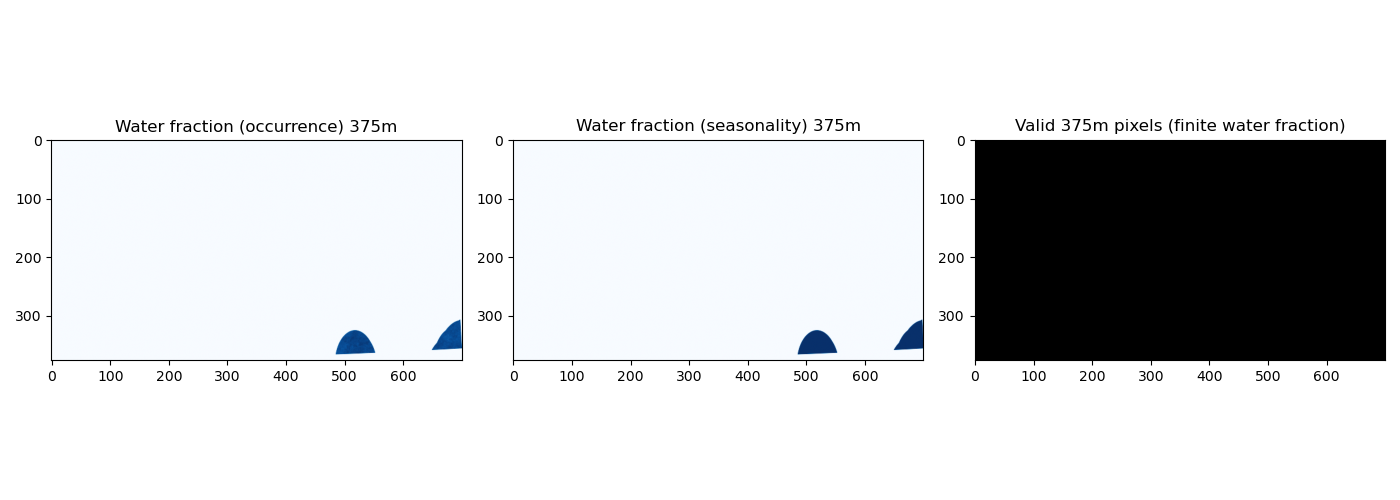

Occurrence 375m: min=0.0000, max=0.9757, mean=0.0122
Seasonality 375m: min=0.0000, max=1.0000, mean=0.0134
Valid pixels (finite in either): 263200 / 263200
(a) Raster shape: 376 rows x 700 cols
(b) 5 example valid (r,c) pixels (finite, with lat/lon and value):
  r=0, c=0, value=0.0000, lat=55.263921, lon=-170.997054
  r=0, c=1, value=0.0000, lat=55.263920, lon=-170.991161
  r=0, c=2, value=0.0000, lat=55.263920, lon=-170.985268
  r=0, c=3, value=0.0000, lat=55.263919, lon=-170.979375
  r=0, c=4, value=0.0000, lat=55.263918, lon=-170.973482
(c) Suggested (r,c) for inspection:
  near-zero (wf<0.01): r=0, c=0, value=0.0000
  mid-range (0.3<=wf<=0.7): r=307, c=696, value=0.6810
  high (wf>0.99): none found


In [53]:
# =============================================================================
# VALIDATION / QA — minimal plots + valid pixels mask
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

v1 = water_fraction_occurrence_375m
v2 = water_fraction_seasonality_375m

axes[0].imshow(v1, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Water fraction (occurrence) 375m")
axes[1].imshow(v2, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Water fraction (seasonality) 375m")

# Valid 375m pixels (finite in either layer)
valid_mask = np.isfinite(v1) | np.isfinite(v2)
axes[2].imshow(valid_mask, cmap="binary", vmin=0, vmax=1)
axes[2].set_title("Valid 375m pixels (finite water fraction)")
plt.tight_layout()
plt.show()

valid1 = np.isfinite(v1)
valid2 = np.isfinite(v2)
print("Occurrence 375m: min={:.4f}, max={:.4f}, mean={:.4f}".format(
    np.nanmin(v1) if valid1.any() else np.nan,
    np.nanmax(v1) if valid1.any() else np.nan,
    np.nanmean(v1) if valid1.any() else np.nan))
print("Seasonality 375m: min={:.4f}, max={:.4f}, mean={:.4f}".format(
    np.nanmin(v2) if valid2.any() else np.nan,
    np.nanmax(v2) if valid2.any() else np.nan,
    np.nanmean(v2) if valid2.any() else np.nan))
print("Valid pixels (finite in either): {:.0f} / {}".format(valid_mask.sum(), valid_mask.size))

def print_suggested_inspection_pixels(wf_375m, transform, crs):
    """Print raster shape, 5 example valid pixels, and suggested (r,c) for inspection."""
    h, w = wf_375m.shape
    print("(a) Raster shape:", h, "rows x", w, "cols")
    finite = np.isfinite(wf_375m)
    rows, cols = np.where(finite)
    if len(rows) == 0:
        print("No finite pixels.")
        return
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    n = min(5, len(rows))
    print("(b) 5 example valid (r,c) pixels (finite, with lat/lon and value):")
    for i in range(n):
        r, c = rows[i], cols[i]
        x = transform.c + (c + 0.5) * transform.a
        y = transform.f + (r + 0.5) * transform.e
        lon, lat = trans.transform(x, y)
        val = wf_375m[r, c]
        print(f"  r={r}, c={c}, value={val:.4f}, lat={lat:.6f}, lon={lon:.6f}")
    def _pf(m):
        rc = np.where(m)
        return (int(rc[0][0]), int(rc[1][0])) if rc[0].size > 0 else None
    land = finite & (wf_375m < 0.01)
    mixed = finite & (wf_375m >= 0.3) & (wf_375m <= 0.7)
    water = finite & (wf_375m > 0.99)
    print("(c) Suggested (r,c) for inspection:")
    for label, rc in [("near-zero (wf<0.01)", _pf(land)), ("mid-range (0.3<=wf<=0.7)", _pf(mixed)), ("high (wf>0.99)", _pf(water))]:
        if rc is not None:
            val = wf_375m[rc[0], rc[1]]
            print(f"  {label}: r={rc[0]}, c={rc[1]}, value={val:.4f}")
        else:
            print(f"  {label}: none found")

print_suggested_inspection_pixels(v1, ref_transform, utm_crs)


OCC vs SEA at same (r,c) — pixels chosen from OCCURRENCE (v1)
------------------------------------------------------------------------------------------
label       r    c        lat        lon   occ_375m   sea_375m delta(sea-occ)
------------------------------------------------------------------------------------------
LAND        0    0  55.263921 -170.997054     0.0000     0.0000        +0.0000
MIXED     307  696  54.164276 -167.004236     0.6810     0.7428        +0.0618
MIXED     308  694  54.161298 -167.016002     0.5506     0.6188        +0.0682
MIXED     309  691  54.158507 -167.033488     0.4659     0.5268        +0.0609
MIXED     309  697  54.157370 -166.999163     0.3547     0.3886        +0.0338
MIXED     310  689  54.155526 -167.045250     0.6965     0.7700        +0.0735
WATER     362  525  54.007927 -167.996901     0.9757     1.0000        +0.0243
------------------------------------------------------------------------------------------

--- LAND pixel (r=0, c=0) — OCCUR

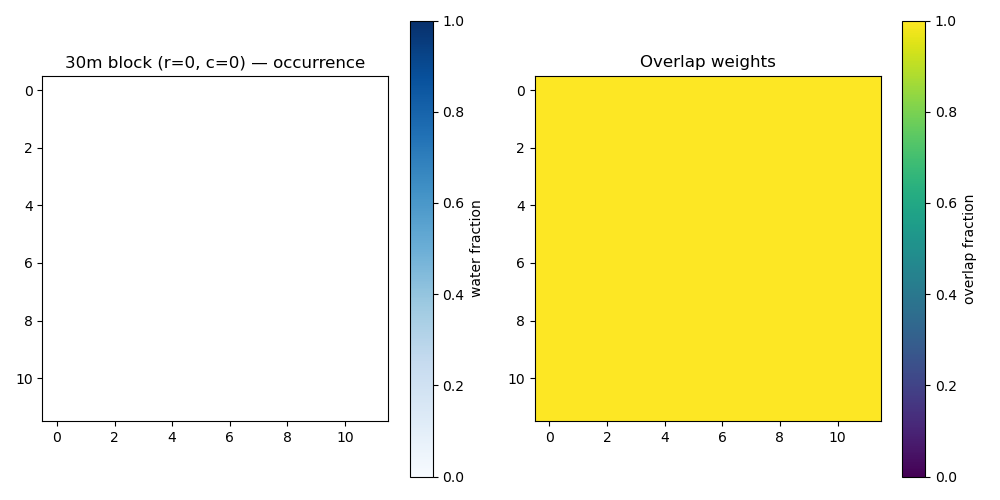


--- LAND pixel (r=0, c=0) — SEASONALITY raster ---
Pixel (r=0, c=0) — raster: seasonality
Center UTM: x=500187.24, y=6124160.89
Center lat/lon: 55.263921, -170.997054
Stored 375m value:         0.000000
Recomputed area-weighted:  0.000000
Total overlap (denominator): 143.997649


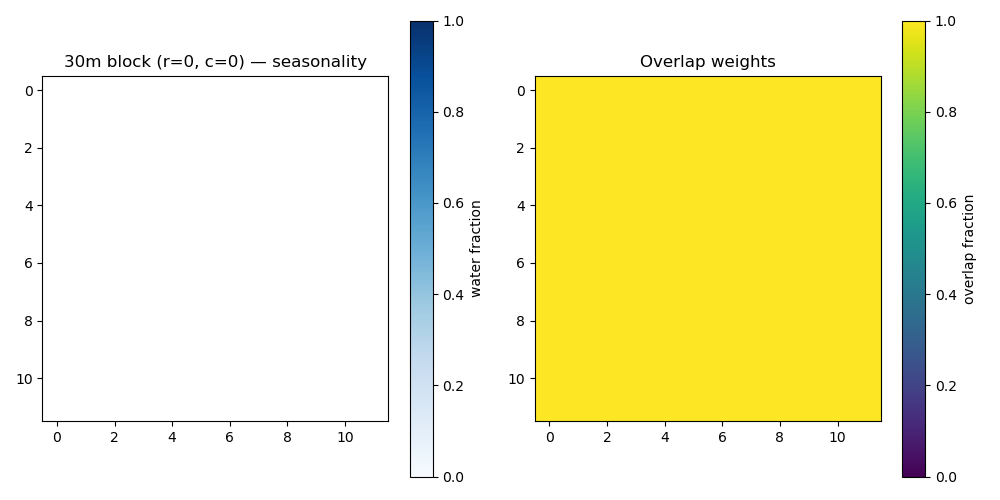


--- MIXED pixel (r=307, c=696) — OCCURRENCE raster ---
Pixel (r=307, c=696) — raster: occurrence
Center UTM: x=760821.71, y=6009177.55
Center lat/lon: 54.164276, -167.004236
Stored 375m value:         0.680988
Recomputed area-weighted:  0.680988
Total overlap (denominator): 138.196730


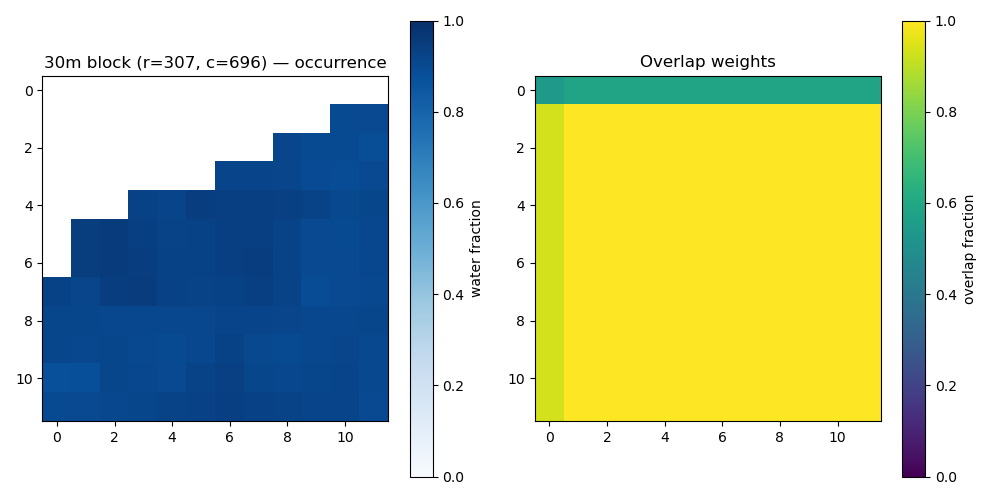


--- MIXED pixel (r=307, c=696) — SEASONALITY raster ---
Pixel (r=307, c=696) — raster: seasonality
Center UTM: x=760821.71, y=6009177.55
Center lat/lon: 54.164276, -167.004236
Stored 375m value:         0.742834
Recomputed area-weighted:  0.742834
Total overlap (denominator): 138.196730


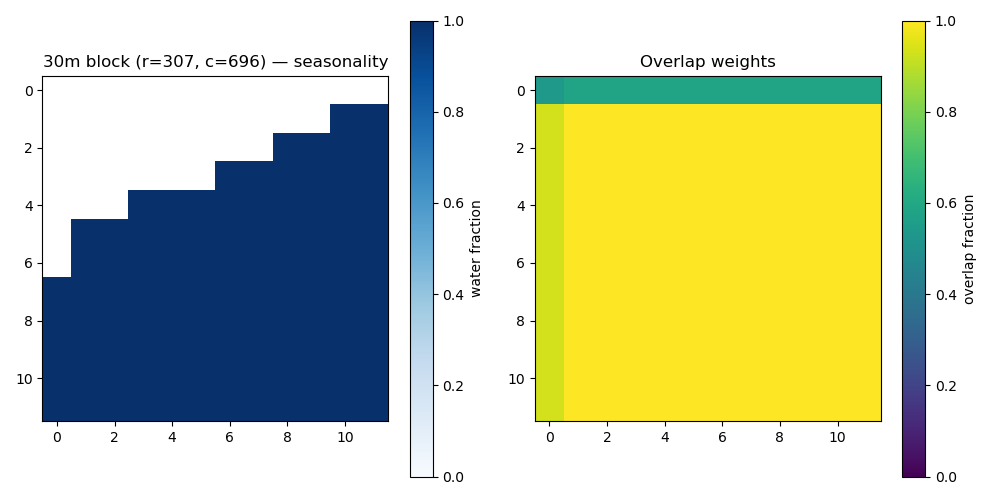


--- MIXED pixel (r=308, c=694) — OCCURRENCE raster ---
Pixel (r=308, c=694) — raster: occurrence
Center UTM: x=760072.76, y=6008803.01
Center lat/lon: 54.161298, -167.016002
Stored 375m value:         0.550629
Recomputed area-weighted:  0.550629
Total overlap (denominator): 132.009244


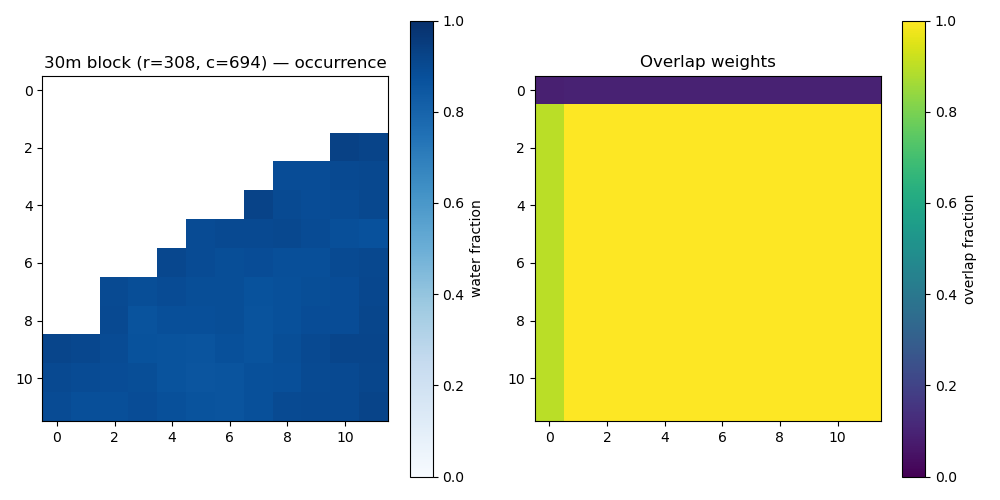


--- MIXED pixel (r=308, c=694) — SEASONALITY raster ---
Pixel (r=308, c=694) — raster: seasonality
Center UTM: x=760072.76, y=6008803.01
Center lat/lon: 54.161298, -167.016002
Stored 375m value:         0.618832
Recomputed area-weighted:  0.618832
Total overlap (denominator): 132.009244


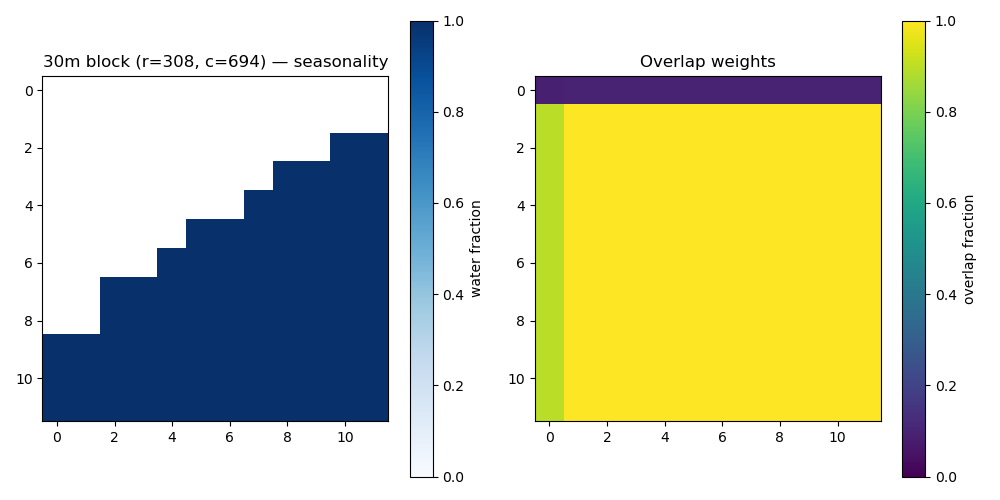


--- MIXED pixel (r=309, c=691) — OCCURRENCE raster ---
Pixel (r=309, c=691) — raster: occurrence
Center UTM: x=758949.33, y=6008428.48
Center lat/lon: 54.158507, -167.033488
Stored 375m value:         0.465854
Recomputed area-weighted:  0.465854
Total overlap (denominator): 131.714427


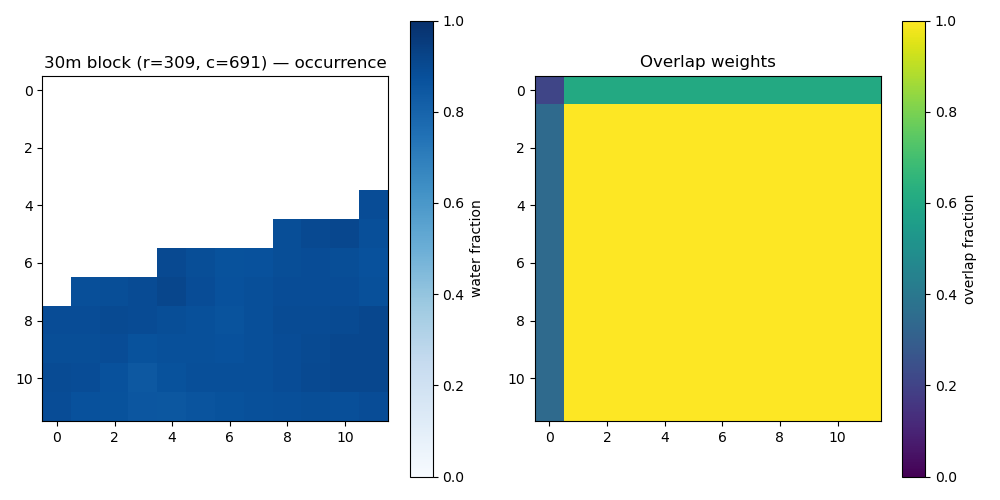


--- MIXED pixel (r=309, c=691) — SEASONALITY raster ---
Pixel (r=309, c=691) — raster: seasonality
Center UTM: x=758949.33, y=6008428.48
Center lat/lon: 54.158507, -167.033488
Stored 375m value:         0.526768
Recomputed area-weighted:  0.526768
Total overlap (denominator): 131.714427


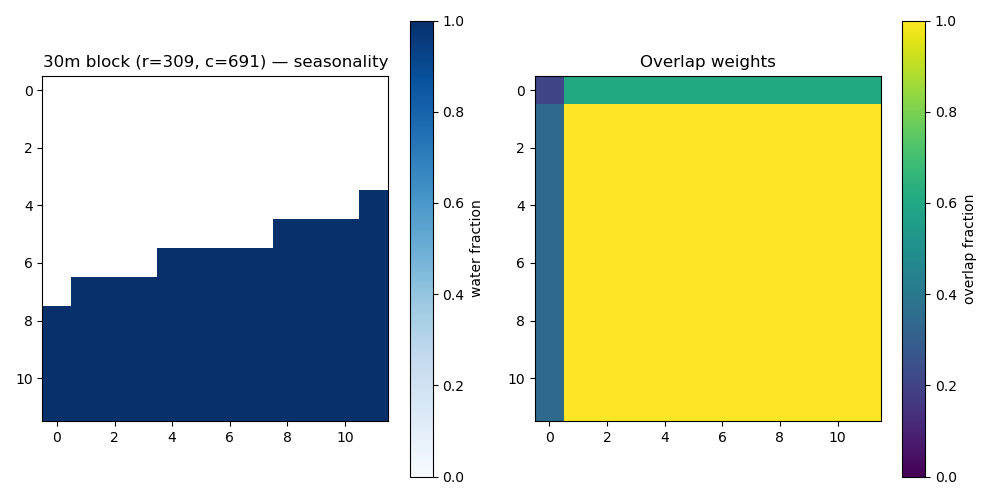


--- MIXED pixel (r=309, c=697) — OCCURRENCE raster ---
Pixel (r=309, c=697) — raster: occurrence
Center UTM: x=761196.18, y=6008428.48
Center lat/lon: 54.157370, -166.999163
Stored 375m value:         0.354740
Recomputed area-weighted:  0.354740
Total overlap (denominator): 132.908517


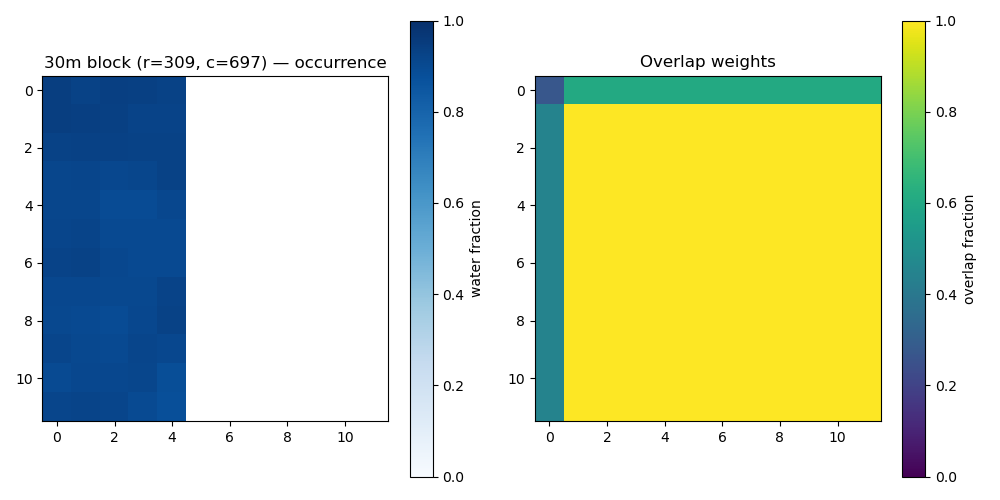


--- MIXED pixel (r=309, c=697) — SEASONALITY raster ---
Pixel (r=309, c=697) — raster: seasonality
Center UTM: x=761196.18, y=6008428.48
Center lat/lon: 54.157370, -166.999163
Stored 375m value:         0.388572
Recomputed area-weighted:  0.388572
Total overlap (denominator): 132.908517


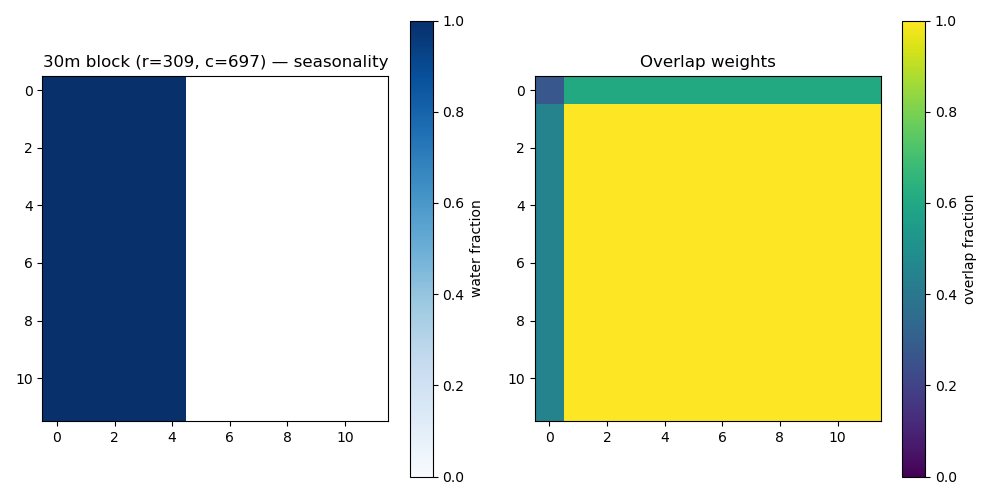


--- MIXED pixel (r=310, c=689) — OCCURRENCE raster ---
Pixel (r=310, c=689) — raster: occurrence
Center UTM: x=758200.38, y=6008053.94
Center lat/lon: 54.155526, -167.045250
Stored 375m value:         0.696468
Recomputed area-weighted:  0.696468
Total overlap (denominator): 125.811097


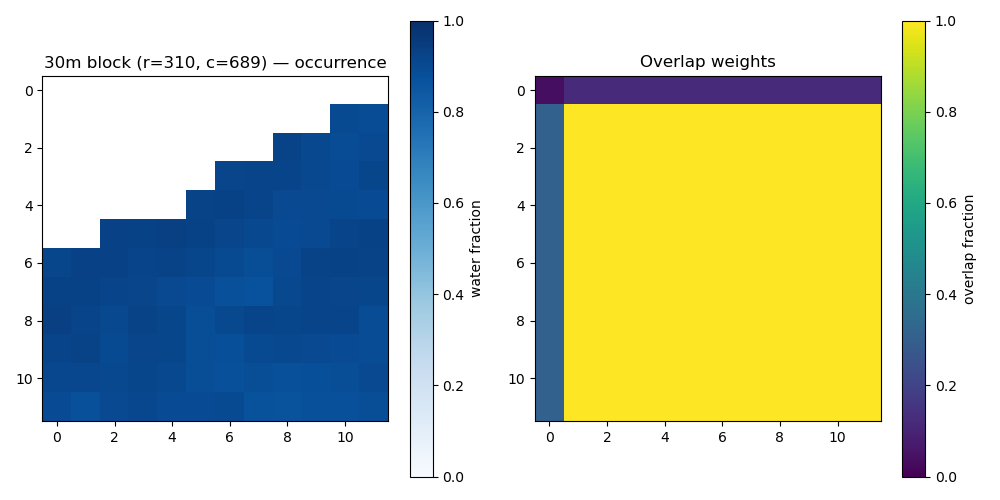


--- MIXED pixel (r=310, c=689) — SEASONALITY raster ---
Pixel (r=310, c=689) — raster: seasonality
Center UTM: x=758200.38, y=6008053.94
Center lat/lon: 54.155526, -167.045250
Stored 375m value:         0.769954
Recomputed area-weighted:  0.769954
Total overlap (denominator): 125.811097


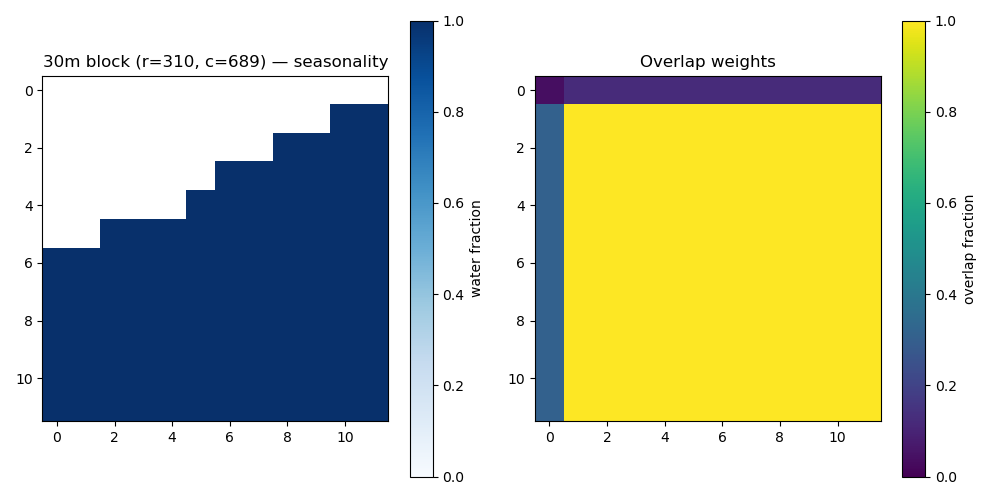


--- WATER pixel (r=362, c=525) — OCCURRENCE raster ---
Pixel (r=362, c=525) — raster: occurrence
Center UTM: x=696786.51, y=5988577.93
Center lat/lon: 54.007927, -167.996901
Stored 375m value:         0.975674
Recomputed area-weighted:  0.975674
Total overlap (denominator): 135.860990


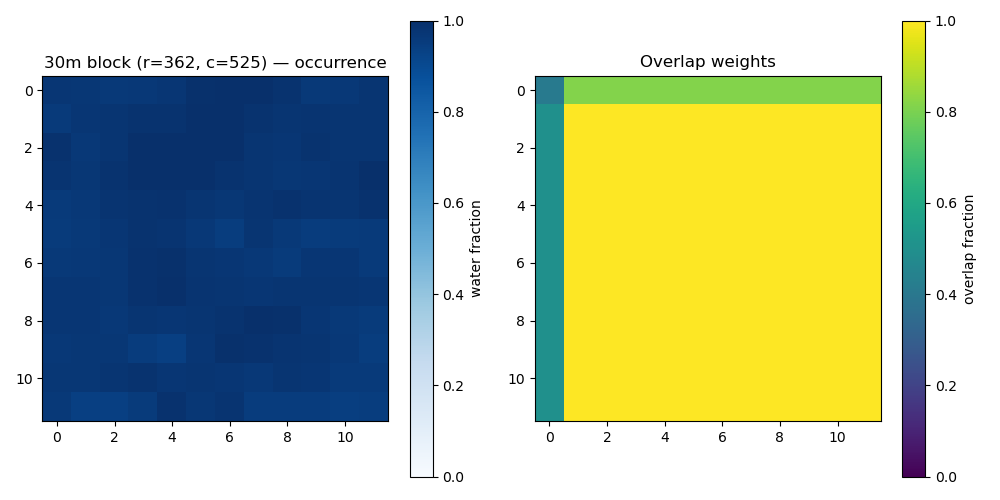


--- WATER pixel (r=362, c=525) — SEASONALITY raster ---
Pixel (r=362, c=525) — raster: seasonality
Center UTM: x=696786.51, y=5988577.93
Center lat/lon: 54.007927, -167.996901
Stored 375m value:         1.000000
Recomputed area-weighted:  1.000000
Total overlap (denominator): 135.860990


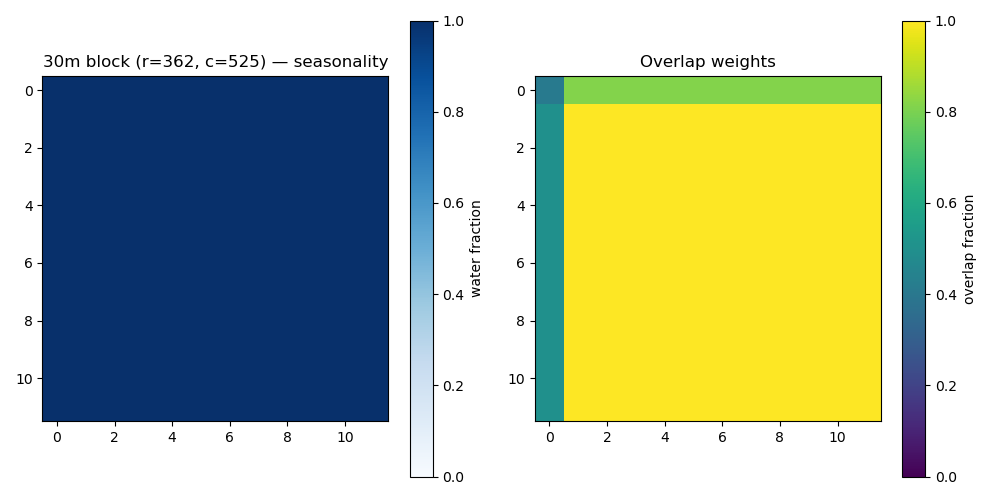

In [54]:
# =============================================================================
# Compare OCC vs SEA at same inspected pixels
# =============================================================================
# Pixels chosen from OCCURRENCE-derived aggregation (v1 = water_fraction_occurrence_375m).
# We inspect BOTH occurrence and seasonality rasters at those SAME (r,c).

# Paths for occurrence vs seasonality (no file overwriting)
path_occ_375 = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
path_sea_375 = os.path.join(OUTPUT_DIR, "water_fraction_seasonality_375m.tif")
path_occ_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_occurrence.tif")
path_sea_30 = os.path.join(OUTPUT_DIR, "jrc_utm_30m_seasonality.tif")

# Reuse occurrence-based pixel selection (v1 from VALIDATION cell)
pixels_occ = pick_n_pixels_by_class(v1, n_land=N_PIXELS_LAND, n_mixed=N_PIXELS_MIXED, n_water=N_PIXELS_WATER)

# Fallbacks if a class has no pixels
finite = np.isfinite(v1)
if not np.any(finite):
    raise ValueError("No valid (finite) pixels in v1. Check coverage/extent.")
wf_finite = np.where(finite, v1, np.nan)
r_min, c_min = np.unravel_index(np.nanargmin(wf_finite), v1.shape)
r_max, c_max = np.unravel_index(np.nanargmax(wf_finite), v1.shape)
has_land = any(p[0] == "LAND" for p in pixels_occ)
has_mixed = any(p[0] == "MIXED" for p in pixels_occ)
has_water = any(p[0] == "WATER" for p in pixels_occ)
if not has_land:
    pixels_occ.append(("LAND", (int(r_min), int(c_min))))
if not has_mixed:
    pixels_occ.append(("MIXED", (int(r_max), int(c_max))))
if not has_water:
    pixels_occ.append(("WATER", (int(r_max), int(c_max))))

def rc_to_latlon(r, c, transform, crs):
    cx = transform.c + (c + 0.5) * transform.a
    cy = transform.f + (r + 0.5) * transform.e
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)
    return lat, lon

# Build summary table: r, c, lat, lon, occ_value_375m, sea_value_375m, delta(sea-occ)
rows = []
for label, rc in pixels_occ:
    r, c = rc
    lat, lon = rc_to_latlon(r, c, ref_transform, utm_crs)
    occ_val = float(v1[r, c]) if np.isfinite(v1[r, c]) else np.nan
    sea_val = float(v2[r, c]) if np.isfinite(v2[r, c]) else np.nan
    delta = (sea_val - occ_val) if np.isfinite(occ_val) and np.isfinite(sea_val) else np.nan
    rows.append((label, r, c, lat, lon, occ_val, sea_val, delta))

print("OCC vs SEA at same (r,c) — pixels chosen from OCCURRENCE (v1)")
print("-" * 90)
print(f"{'label':<8} {'r':>4} {'c':>4} {'lat':>10} {'lon':>10} {'occ_375m':>10} {'sea_375m':>10} {'delta(sea-occ)':>14}")
print("-" * 90)
for label, r, c, lat, lon, occ_val, sea_val, delta in rows:
    occ_s = f"{occ_val:.4f}" if np.isfinite(occ_val) else "nan"
    sea_s = f"{sea_val:.4f}" if np.isfinite(sea_val) else "nan"
    delta_s = f"{delta:+.4f}" if np.isfinite(delta) else "nan"
    print(f"{label:<8} {r:>4} {c:>4} {lat:>10.6f} {lon:>10.6f} {occ_s:>10} {sea_s:>10} {delta_s:>14}")
print("-" * 90)

# Run inspector twice per pixel: once for occurrence raster, once for seasonality raster
for label, rc in pixels_occ:
    r, c = rc
    print(f"\n--- {label} pixel (r={r}, c={c}) — OCCURRENCE raster ---")
    inspect_375m_pixel_contribution(r, c, path_375=path_occ_375, path_30=path_occ_30, raster_label="occurrence")
    print(f"\n--- {label} pixel (r={r}, c={c}) — SEASONALITY raster ---")
    inspect_375m_pixel_contribution(r, c, path_375=path_sea_375, path_30=path_sea_30, raster_label="seasonality")



WATER not found in this AOI (no wf>0.99 pixels). Fallback to max wf pixel.
Chosen pixels:
  LAND: r=0, c=0, wf=0.0000, lat=55.263921, lon=-170.997054, UTM x=500187.2, y=6124160.9
  MIXED: r=307, c=696, wf=0.6810, lat=54.164276, lon=-167.004236, UTM x=760821.7, y=6009177.6
  MIXED: r=308, c=694, wf=0.5506, lat=54.161298, lon=-167.016002, UTM x=760072.8, y=6008803.0
  MIXED: r=309, c=691, wf=0.4659, lat=54.158507, lon=-167.033488, UTM x=758949.3, y=6008428.5
  MIXED: r=309, c=697, wf=0.3547, lat=54.157370, lon=-166.999163, UTM x=761196.2, y=6008428.5
  MIXED: r=310, c=689, wf=0.6965, lat=54.155526, lon=-167.045250, UTM x=758200.4, y=6008053.9
  WATER: r=362, c=525, wf=0.9757, lat=54.007927, lon=-167.996901, UTM x=696786.5, y=5988577.9

--- Inspecting LAND pixel ---
Pixel (r=0, c=0) — raster: occurrence
Center UTM: x=500187.24, y=6124160.89
Center lat/lon: 55.263921, -170.997054
Stored 375m value:         0.000000
Recomputed area-weighted:  0.000000
Total overlap (denominator): 143.997649

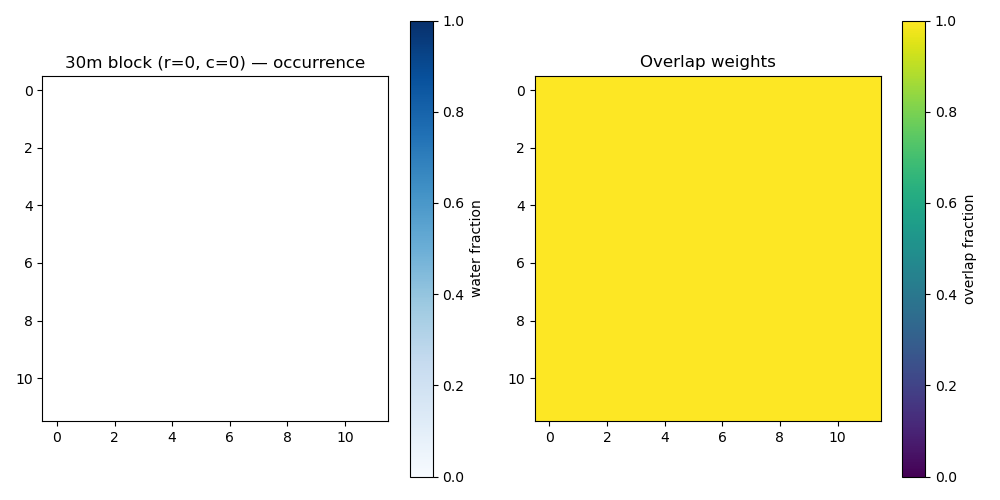


--- Inspecting MIXED pixel ---
Pixel (r=307, c=696) — raster: occurrence
Center UTM: x=760821.71, y=6009177.55
Center lat/lon: 54.164276, -167.004236
Stored 375m value:         0.680988
Recomputed area-weighted:  0.680988
Total overlap (denominator): 138.196730


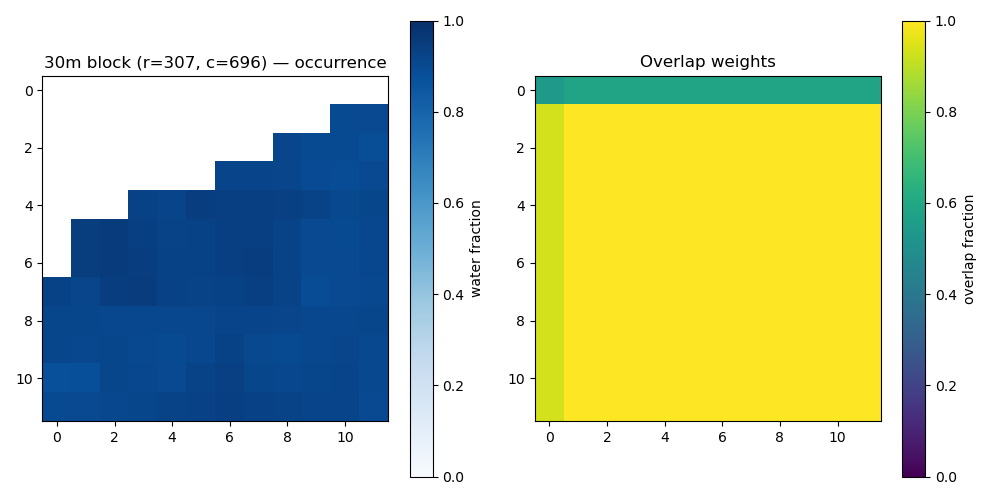


--- Inspecting MIXED pixel ---
Pixel (r=308, c=694) — raster: occurrence
Center UTM: x=760072.76, y=6008803.01
Center lat/lon: 54.161298, -167.016002
Stored 375m value:         0.550629
Recomputed area-weighted:  0.550629
Total overlap (denominator): 132.009244


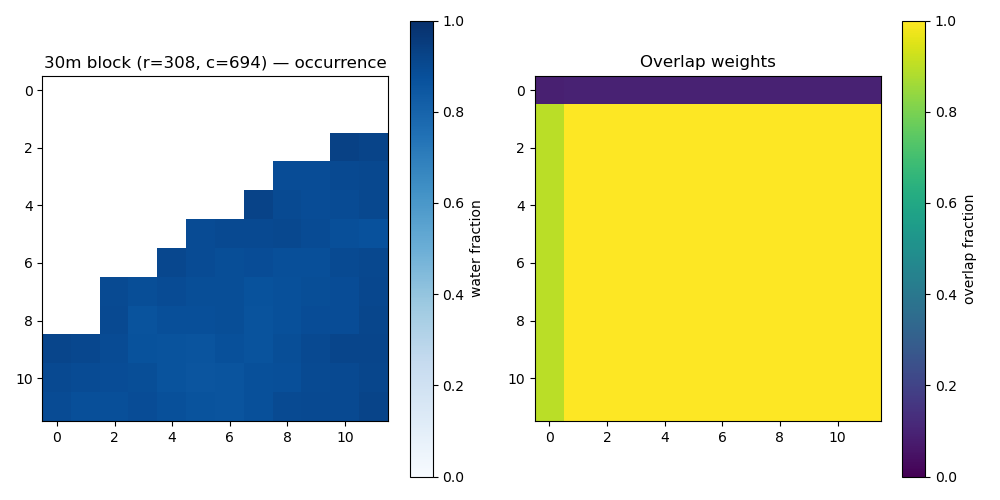


--- Inspecting MIXED pixel ---
Pixel (r=309, c=691) — raster: occurrence
Center UTM: x=758949.33, y=6008428.48
Center lat/lon: 54.158507, -167.033488
Stored 375m value:         0.465854
Recomputed area-weighted:  0.465854
Total overlap (denominator): 131.714427


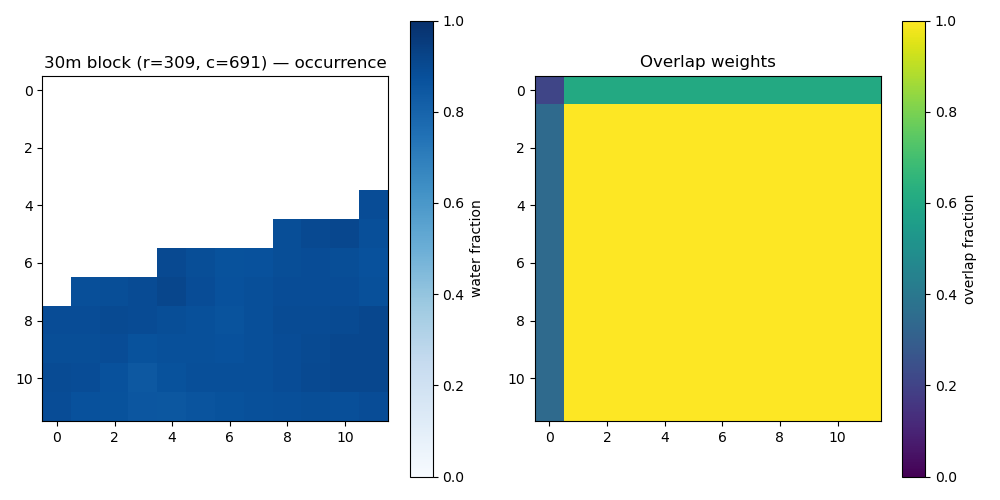


--- Inspecting MIXED pixel ---
Pixel (r=309, c=697) — raster: occurrence
Center UTM: x=761196.18, y=6008428.48
Center lat/lon: 54.157370, -166.999163
Stored 375m value:         0.354740
Recomputed area-weighted:  0.354740
Total overlap (denominator): 132.908517


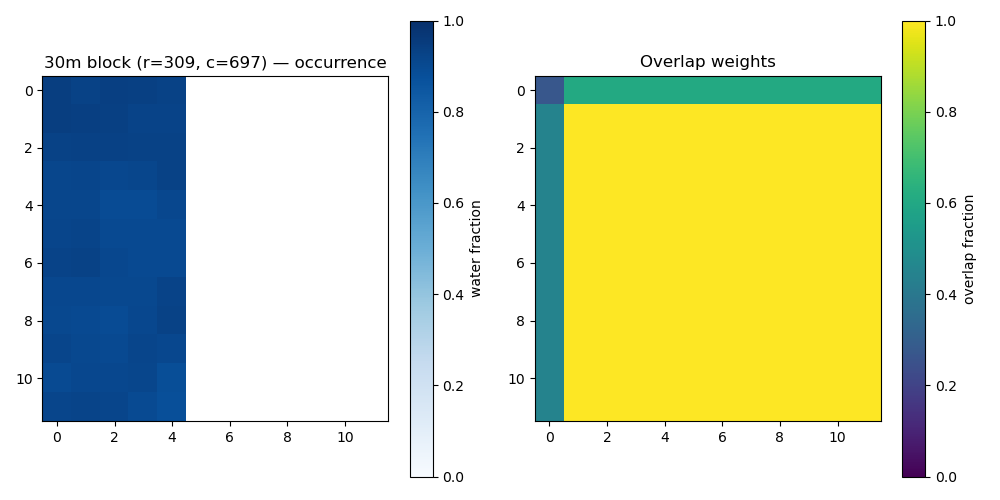


--- Inspecting MIXED pixel ---
Pixel (r=310, c=689) — raster: occurrence
Center UTM: x=758200.38, y=6008053.94
Center lat/lon: 54.155526, -167.045250
Stored 375m value:         0.696468
Recomputed area-weighted:  0.696468
Total overlap (denominator): 125.811097


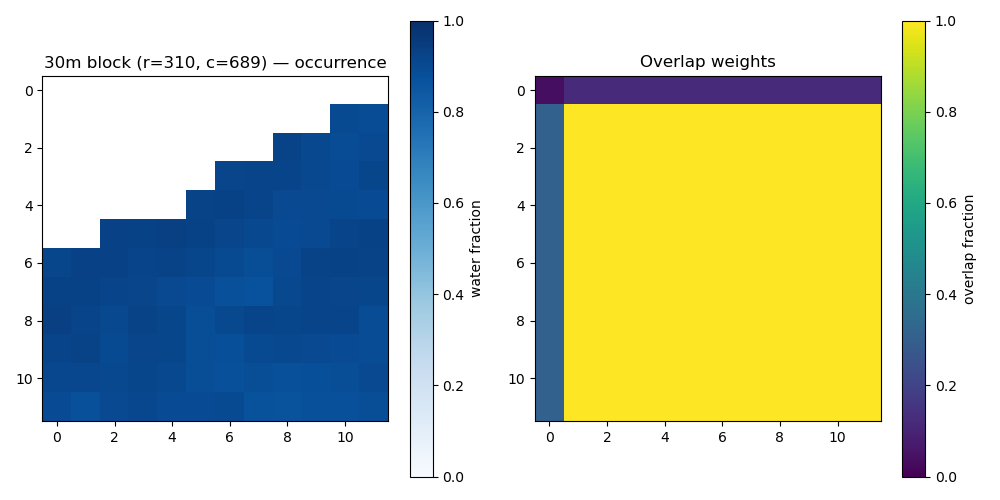


--- Inspecting WATER pixel ---
Pixel (r=362, c=525) — raster: occurrence
Center UTM: x=696786.51, y=5988577.93
Center lat/lon: 54.007927, -167.996901
Stored 375m value:         0.975674
Recomputed area-weighted:  0.975674
Total overlap (denominator): 135.860990


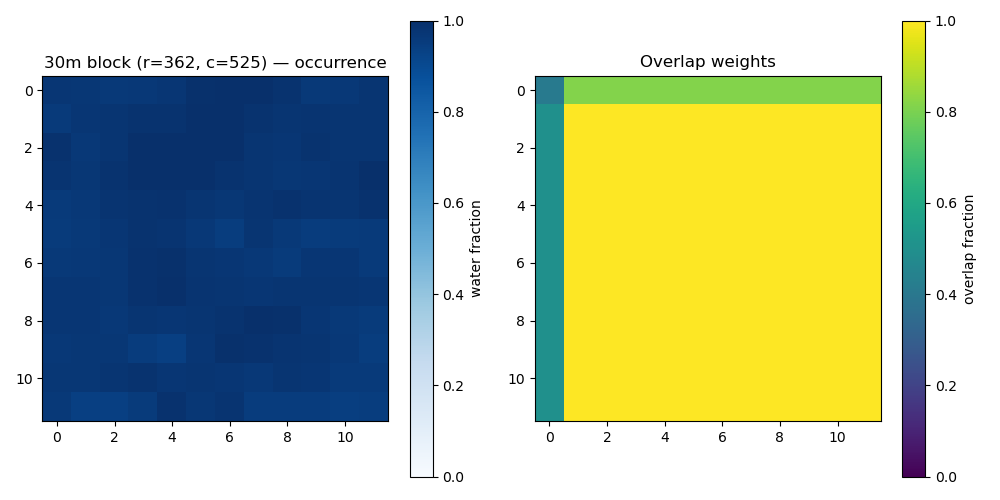

In [55]:
# =============================================================================
# Run Inspector Examples — automatic pixel selection by class
# =============================================================================
# Load wf_375m from disk (robust if cells run out of order)
path_wf = os.path.join(OUTPUT_DIR, "water_fraction_occurrence_375m.tif")
if not os.path.exists(path_wf):
    raise FileNotFoundError(f"Run pipeline first. Need {path_wf}")

with rasterio.open(path_wf) as src:
    wf = src.read(1).astype(np.float32)
    tf = src.transform
    crs = src.crs
    if src.nodata is not None:
        wf[wf == src.nodata] = np.nan

pixels = pick_n_pixels_by_class(wf, n_land=N_PIXELS_LAND, n_mixed=N_PIXELS_MIXED, n_water=N_PIXELS_WATER)

# Fallback if a class has no pixels
finite = np.isfinite(wf)
if not np.any(finite):
    raise ValueError("No valid (finite) pixels in wf_375m. Check coverage/extent.")

wf_finite = np.where(finite, wf, np.nan)
r_min, c_min = np.unravel_index(np.nanargmin(wf_finite), wf.shape)
r_max, c_max = np.unravel_index(np.nanargmax(wf_finite), wf.shape)

has_land = any(p[0] == "LAND" for p in pixels)
has_mixed = any(p[0] == "MIXED" for p in pixels)
has_water = any(p[0] == "WATER" for p in pixels)
if not has_land:
    pixels.append(("LAND", (int(r_min), int(c_min))))
    print("LAND not found (no wf<0.01); fallback to min wf pixel")
if not has_mixed:
    pixels.append(("MIXED", (int(r_max), int(c_max))))
    print("MIXED not found (no 0.3<wf<0.7); fallback to max wf pixel")
if not has_water:
    pixels.append(("WATER", (int(r_max), int(c_max))))
    print("WATER not found in this AOI (no wf>0.99 pixels). Fallback to max wf pixel.")

def rc_to_latlon(r, c, transform, crs):
    cx = transform.c + (c + 0.5) * transform.a
    cy = transform.f + (r + 0.5) * transform.e
    trans = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = trans.transform(cx, cy)
    return lat, lon, cx, cy

print("Chosen pixels:")
for label, rc in pixels:
    r, c = rc
    val = wf[r, c]
    lat, lon, cx, cy = rc_to_latlon(r, c, tf, crs)
    print(f"  {label}: r={r}, c={c}, wf={val:.4f}, lat={lat:.6f}, lon={lon:.6f}, UTM x={cx:.1f}, y={cy:.1f}")

# Run inspector for each pixel
for label, rc in pixels:
    print(f"\n--- Inspecting {label} pixel ---")
    inspect_375m_pixel_contribution(rc[0], rc[1])

